# 5. Color: Spaces, Palettes, Extraction

Today we treat color as data. We watch a painting scatter into a cube of numbers, teach the computer to distill a palette from it, and then let Monet recolor everything we have built so far.

## Today's destination

A triptych: three generators from the previous chapters (random walks, a chance grid, a subdivision composition), all painted with a palette that no one designed. It was *extracted*, by a clustering algorithm, from Claude Monet's water lilies. By the end of this chapter you can harvest a palette from any image and hand it to any of your systems.

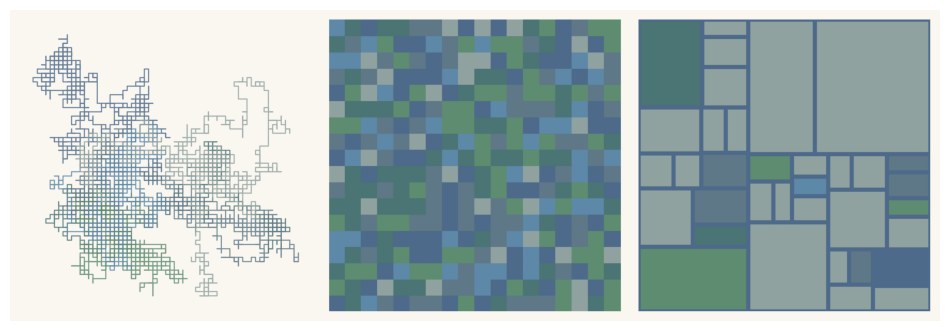

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch05_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(12, 4.5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: color as an empirical problem

At the Bauhaus, **Johannes Itten** made color one of the pillars of his legendary preliminary course (the Vorkurs you met in chapter 0): his twelve-part color wheel and his seven kinds of color contrast (hue, light-dark, warm-cold, complementary, simultaneous, saturation, extension), fully codified only decades later in *Kunst der Farbe* (1961), gave a generation of artists a *system* for talking about something that had long been treated as ineffable taste. His student and successor in the Vorkurs, **Josef Albers**, went further and turned color theory into experiment. The premise of his *Interaction of Color* (1963) is that color is never seen alone: "In visual perception a color is almost never seen as it really is, as it physically is." The book's famous plates prove it: the same physical color, laid on two different grounds, refuses to look like the same color. We will reconstruct that demonstration in code in a moment, and you will not believe your own eyes, which is precisely Albers' point.

Painters had exploited this long before it was theorized. The Impressionists scandalized critics by painting shadows violet and blue: not because pigment fashion changed, but because they looked harder. A shadow on sunlit snow really is bluish (it is lit by the sky, not the sun), and the warm-cold vibration between sunlight and shadow does more optical work than any amount of gray. **Claude Monet**, whose water lilies provide today's raw data, built entire late paintings out of such interactions, and **Mark Rothko**'s stacked fields live almost entirely on the slow hum between two large adjacent colors.

For us the practical consequence is this: if color is *relational*, then the numbers we store colors in matter. The RGB numbers a screen wants are physically convenient and perceptually wrong: two color pairs can be equally far apart in RGB while one pair looks nearly identical and the other obviously different. Color science's answer is **CIELAB**, a color space bent so that numeric distance approximates perceived difference. Today we meet both spaces, and we put LAB to work: a clustering algorithm that groups a painting's pixels finds "the" palette of the painting, but only if it measures distance the way an eye would.

## Albers, reconstructed

Two panels, each with a small rectangle sitting on a large ground. Look at the two small rectangles: which one is lighter, the left or the right?

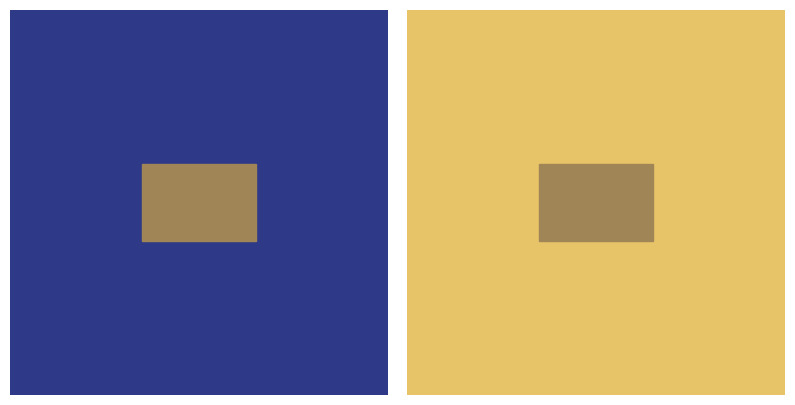

In [2]:
# the same inner color on two grounds -- which small rectangle is lighter?
from matplotlib.patches import Rectangle

inner_color = "#A08556"                       # one single color, used twice
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, ground in [(axes[0], "#2E3A87"), (axes[1], "#E8C468")]:
    ax.add_patch(Rectangle((0, 0), 1, 1, color=ground))
    ax.add_patch(Rectangle((0.35, 0.4), 0.3, 0.2, color=inner_color))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
plt.subplots_adjust(wspace=0.05)
plt.show()

Most people see the left rectangle as lighter and warmer, and the right one as darker and duller. The code above tells the truth: both are `"#A08556"`, byte for byte. Your visual system computes color *relative to its surround* (simultaneous contrast, Simultankontrast); the dark blue ground pushes its tenant toward light, the sandy ground pushes it toward dark. Albers built a whole pedagogy on such plates, and his deeper lesson is ours too: **the artist controls relations, not pixels.** If you doubt the trick, the cell below pulls both rectangles out of their grounds and lets them touch.

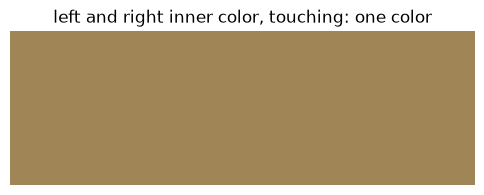

In [3]:
# proof: the two inner rectangles, side by side with no grounds
fig, ax = plt.subplots(figsize=(6, 2))
ax.add_patch(Rectangle((0, 0), 1, 1, color=inner_color))
ax.add_patch(Rectangle((1, 0), 1, 1, color=inner_color))
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("left and right inner color, touching: one color")
plt.show()

## A painting is a cloud of points

Time for the data view. From chapter 2 you know that a digital image is an array of shape `(rows, cols, 3)`: one red, green, and blue value per pixel. Flip that around: every pixel is a point $(r, g, b)$ in a three-dimensional **RGB cube**. A painting is a cloud of a few million such points, and the *shape* of that cloud is the painting's color identity.

We load Monet's *Water Lilies* from the course image folder. (If the file is missing, run `python assets/images/get_images.py` once in a terminal, from the book's main folder, the one that contains `assets/`; it fetches public-domain paintings from Wikimedia Commons, or builds synthetic stand-ins when offline.)

Three numpy moves appear in the next cells, worth naming once. `reshape(-1, 3)` re-pours the same numbers into a new shape (the `-1` means "however many rows it takes"); `pixels[chosen]` picks whole rows out by their index numbers; `sample[:, 0]` takes one column. That is most of the numpy indexing you will ever need.

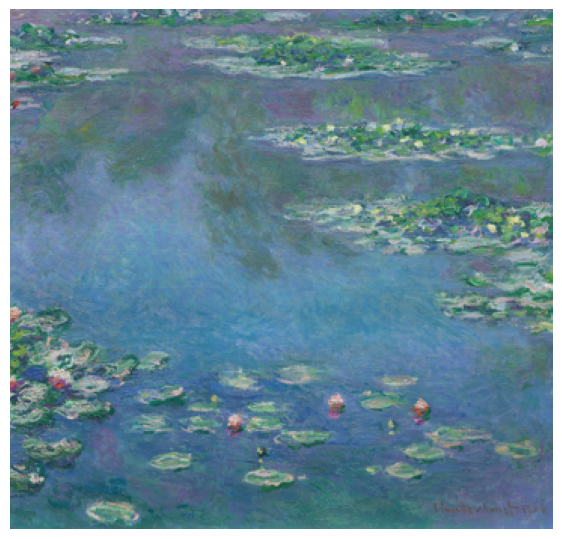

array shape: (345, 360, 3)


In [4]:
# load the Monet and downscale it -- all analysis runs on the small version
import numpy as np
from PIL import Image

image_path = "../assets/images/monet_waterlilies.jpg"
original = Image.open(image_path)
width = 360                                    # small is plenty for statistics
height = int(original.height * width / original.width)
painting = np.asarray(original.resize((width, height))) / 255

plt.figure(figsize=(7, 7))
plt.imshow(painting)
plt.axis("off")
plt.show()
print("array shape:", painting.shape)

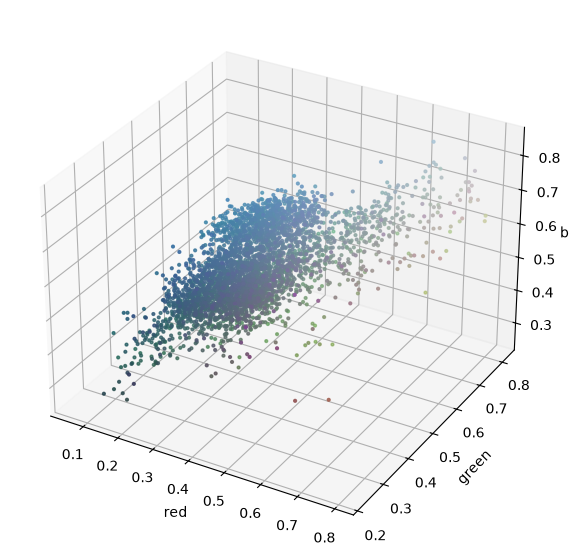

In [5]:
# every pixel is a point in the RGB cube -- scatter a few thousand of them
pixels = painting.reshape(-1, 3)               # flatten to a list of pixels
rng = np.random.default_rng(5)
chosen = rng.choice(len(pixels), size=4000, replace=False)
sample = pixels[chosen]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")
ax.scatter(sample[:, 0], sample[:, 1], sample[:, 2], c=sample, s=4)
ax.set_xlabel("red")
ax.set_ylabel("green")
ax.set_zlabel("blue")
plt.show()

Each dot is drawn in its own color, so you are looking at the painting's palette as a cloud: Monet's greens and blues form a dense diagonal ridge, with sparse runners toward the pinks of the blossoms. Rotate this plot in your head (or re-run with a different `seed` in `rng`): no histogram tells you as much about a painting's color as this one scatter.

## Hue, and the trouble with cubes

RGB describes what the *screen* does (three lamps at some brightness), not what *we* see. Humans reach more naturally for hue (Farbton: which color?), saturation (how vivid?), and value (how light?): the **HSV** re-coordinates of the same cube. You met hue in chapter 2, when the Kelly spectrum drifted it across a grid and wrapped it with `% 1.0`; here is the whole system at a glance.

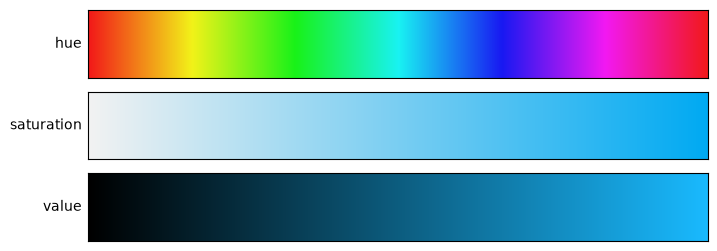

In [6]:
# HSV at a glance: vary one coordinate, hold the other two
import colorsys

strip = np.zeros((3, 256, 3))
for i in range(256):
    strip[0, i] = colorsys.hsv_to_rgb(i / 256, 0.9, 0.95)   # hue varies
    strip[1, i] = colorsys.hsv_to_rgb(0.55, i / 256, 0.95)  # saturation varies
    strip[2, i] = colorsys.hsv_to_rgb(0.55, 0.9, i / 256)   # value varies

fig, axes = plt.subplots(3, 1, figsize=(8, 3))
for row, label in [(0, "hue"), (1, "saturation"), (2, "value")]:
    axes[row].imshow(strip[row:row + 1], aspect="auto")
    axes[row].set_ylabel(label, rotation=0, ha="right", va="center")
    axes[row].set_xticks([])
    axes[row].set_yticks([])
plt.show()

## Perceptual distance: CIELAB

HSV is friendlier than RGB, but neither measures **difference** the way an eye does. The demonstration below shows two pairs of colors. Within each pair, the two colors are exactly equally far apart in RGB (a distance of 60 units in both cases). Yet the left pair looks obviously different, while the right pair looks far more alike.

**CIELAB** (or LAB) fixes this: it re-bends the color cube using measurements of human vision, into a lightness axis $L^*$ and two opponent axes $a^*$ (green–red) and $b^*$ (blue–yellow). Straight-line distance in LAB, called $\Delta E$, approximates perceived difference: $\Delta E \approx 2$ sits at the threshold of visibility, and the larger the value, the clearer the difference. The cell computes $\Delta E$ for both pairs: equally far apart in RGB, yet more than twice as far apart to the eye.

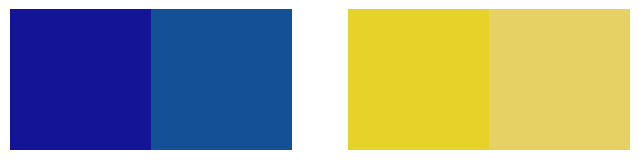

left  pair: RGB distance 60, LAB distance 47
right pair: RGB distance 60, LAB distance 22


In [7]:
# two pairs, equally far apart in RGB -- but not to your eyes, and not in LAB
from skimage.color import rgb2lab

pair_left = np.array([[20, 20, 150], [20, 80, 150]]) / 255    # two blues
pair_right = np.array([[230, 210, 40], [230, 210, 100]]) / 255  # two yellows

fig, axes = plt.subplots(1, 2, figsize=(8, 2.6))
axes[0].imshow(pair_left.reshape(1, 2, 3))
axes[1].imshow(pair_right.reshape(1, 2, 3))
for ax in axes:
    ax.axis("off")
plt.show()

for name, pair in [("left ", pair_left), ("right", pair_right)]:
    rgb_distance = np.linalg.norm(pair[0] - pair[1]) * 255
    lab_pair = rgb2lab(pair.reshape(1, 2, 3)).reshape(2, 3)
    delta_e = np.linalg.norm(lab_pair[0] - lab_pair[1])
    print(f"{name} pair: RGB distance {rgb_distance:.0f}, LAB distance {delta_e:.0f}")

## Finding "the" palette: k-means

Now the harvest. We want the six colors that best summarize the painting: six points in color space such that every pixel is close to one of them. The classic algorithm is **k-means clustering**, and its whole idea fits in three lines:

1. Guess $k$ cluster centers.
2. **Assign** every pixel to its nearest center.
3. **Average** each cluster's pixels to get a better center. Repeat 2 and 3 until nothing moves.

The averaging is why the color space matters: run k-means in RGB and the "nearest center" step uses the distance we just discredited. We run it in LAB, on the downscaled painting, using scikit-learn's implementation (the algorithm is not today's lesson; the space it runs in is).

In [8]:
# k-means in LAB: six clusters summarize the painting
from sklearn.cluster import KMeans

painting_lab = rgb2lab(painting)               # convert the whole small image
pixels_lab = painting_lab.reshape(-1, 3)

kmeans = KMeans(n_clusters=6, n_init=10, random_state=0)
labels = kmeans.fit_predict(pixels_lab)        # cluster number of every pixel
centers_lab = kmeans.cluster_centers_
print("cluster sizes:", np.bincount(labels))

cluster sizes: [11177 24615 29274  7985 28387 22762]


extracted palette: ['#4e6a8a', '#4b7475', '#5e7888', '#5d8c70', '#5d88a8', '#90a2a0']


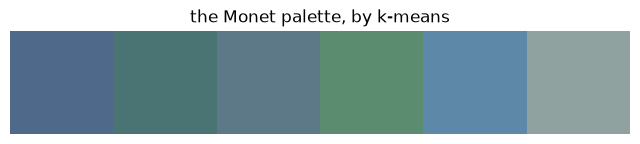

In [9]:
# the six centers, converted back to RGB and sorted dark to light
from skimage.color import lab2rgb
from matplotlib.colors import to_hex

order = np.argsort(centers_lab[:, 0])          # column 0 of LAB is lightness
centers_rgb = lab2rgb(centers_lab[order].reshape(1, 6, 3)).reshape(6, 3)

monet_palette = []
for center in centers_rgb:
    monet_palette.append(to_hex(center))
print("extracted palette:", monet_palette)

plt.figure(figsize=(8, 1.4))
plt.imshow(centers_rgb.reshape(1, 6, 3))
plt.axis("off")
plt.title("the Monet palette, by k-means")
plt.show()

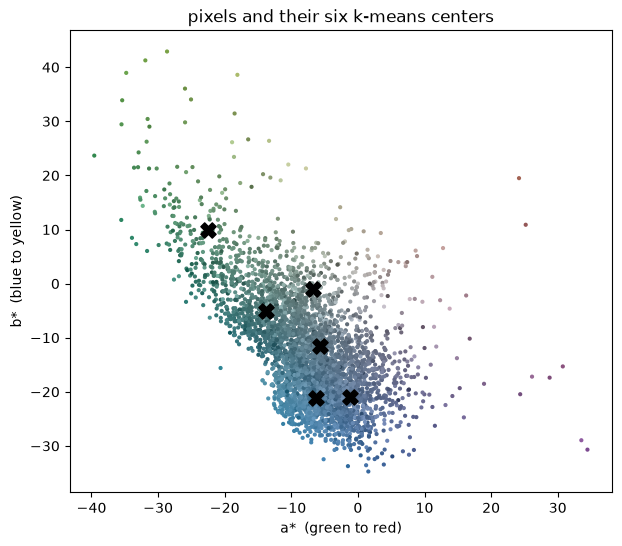

In [10]:
# where the clusters live: the painting's pixels on the a*-b* plane
sample_lab = pixels_lab[chosen]                # same 4000 pixels as before

plt.figure(figsize=(7, 6))
plt.scatter(sample_lab[:, 1], sample_lab[:, 2], c=sample, s=4)
plt.scatter(centers_lab[:, 1], centers_lab[:, 2], c="black", s=120, marker="X")
plt.xlabel("a*  (green to red)")
plt.ylabel("b*  (blue to yellow)")
plt.title("pixels and their six k-means centers")
plt.show()

The black crosses are the six centers: each sits in the middle of a dense region of pixels, exactly as "assign, average, repeat" promises.

## The painting, quantized to itself

A quick test of how well six colors summarize the painting: repaint every pixel with its cluster's center color. This is **quantization** (chapter 12 will push it much further, down to one bit).

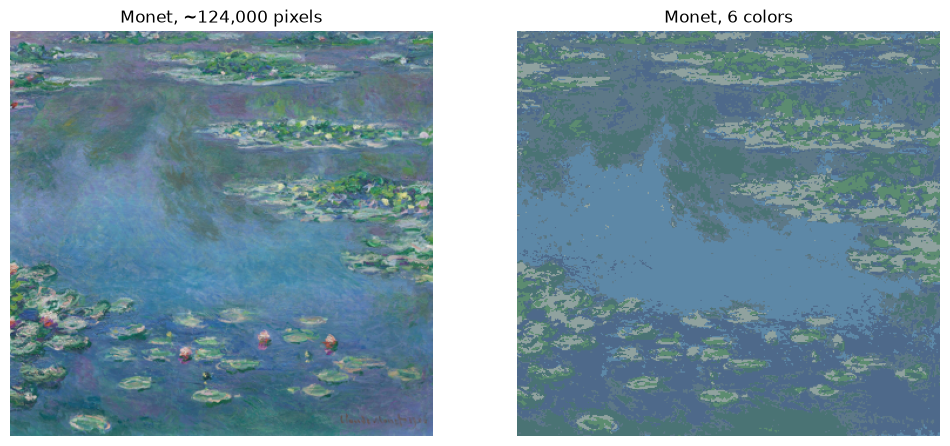

In [11]:
# repaint every pixel with its cluster center: the painting in six colors
centers_rgb_unsorted = lab2rgb(centers_lab.reshape(1, 6, 3)).reshape(6, 3)
# labels holds each pixel's cluster number; indexing the center list with it
# swaps every pixel for its center in one stroke
quantized = centers_rgb_unsorted[labels].reshape(painting.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(painting)
axes[0].set_title("Monet, ~124,000 pixels")
axes[1].imshow(quantized)
axes[1].set_title("Monet, 6 colors")
for ax in axes:
    ax.axis("off")
plt.show()

## Palette transfer: Monet recolors our machines

Here is the payoff. Our course palettes live in the dictionary `agap.PALETTES`, and a dictionary can always take one more entry: we register the extracted palette under the name `"monet"`, and every generator we have built can use it by name, instantly.

To put three generators side by side, we bring back one function from each of chapters 1, 2, and 4, condensed, with one small change: each draws onto an axis `ax` that we hand it, instead of making its own figure (the trick behind chapter 4's six-panel sheet). Copying your own functions forward like this is honest reuse; in chapter 22 it becomes the official recipe for combined artworks. (One archaism travels along: chapter 1 was written before our numpy convention, so its condensed panel still rolls its dice with the old `random` module, the only such exception in the book.)

In [12]:
# register the extracted palette as a course palette
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

PALETTES["monet"] = monet_palette
print("palettes now:", list(PALETTES.keys()))

palettes now: ['bauhaus', 'rothko_dark', 'pastel', 'monochrome', 'viridis', 'magma', 'kelly', 'monet']


In [13]:
# chapter 1's random walks, condensed: draws onto a given axis
import random

def walk_panel(ax, palette_name, n_walkers=6, n_steps=1500, seed=3):
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    palette = PALETTES[palette_name]
    random.seed(seed)
    for walker in range(n_walkers):
        x = 0
        y = 0
        xs = [x]
        ys = [y]
        for step in range(n_steps):
            dx, dy = random.choice(directions)
            x = x + dx
            y = y + dy
            xs.append(x)
            ys.append(y)
        ax.plot(xs, ys, linewidth=0.8,
                color=palette[walker % len(palette)], alpha=0.85)
    ax.set_aspect("equal")
    ax.axis("off")

In [14]:
# chapter 2's chance grid, condensed: weights favor the darker colors
def grid_panel(ax, palette_name, rows=18, cols=18, seed=3):
    palette = PALETTES[palette_name]
    rng = np.random.default_rng(seed)
    weights = np.linspace(2.0, 1.0, len(palette))   # dark common, light rare
    weights = weights / np.sum(weights)
    for row in range(rows):
        for col in range(cols):
            index = rng.choice(len(palette), p=weights)
            ax.add_patch(Rectangle((col, row), 1.0, 1.0, color=palette[index]))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.axis("off")

In [15]:
# chapter 4's recursive splitter (same logic, condensed line breaks)
def subdivide(x, y, width, height, depth, stop_chance, rng,
              min_size=0.1, calm_area=0.25):
    finished = depth == 0 or width < min_size or height < min_size
    may_rest = width * height < calm_area
    if finished or (may_rest and rng.random() < stop_chance):
        return [(x, y, width, height)]
    ratio = rng.uniform(0.35, 0.65)
    if width >= height:
        return (subdivide(x, y, width * ratio, height, depth - 1, stop_chance, rng)
                + subdivide(x + width * ratio, y, width * (1 - ratio), height,
                            depth - 1, stop_chance, rng))
    return (subdivide(x, y, width, height * ratio, depth - 1, stop_chance, rng)
            + subdivide(x, y + height * ratio, width, height * (1 - ratio),
                        depth - 1, stop_chance, rng))

In [16]:
# chapter 4's mondrian panel: lightest color as ground, darkest as line color
def mondrian_panel(ax, palette_name, depth=7, stop_chance=0.4, border=3,
                   accent_chance=0.35, seed=11):
    palette = PALETTES[palette_name]
    rng = np.random.default_rng(seed)
    for x, y, width, height in subdivide(0, 0, 1, 1, depth, stop_chance, rng):
        color = palette[-1]                       # the lightest color as ground
        if rng.random() < accent_chance:
            color = palette[rng.integers(0, len(palette) - 1)]
        ax.add_patch(Rectangle((x, y), width, height, facecolor=color,
                               edgecolor=palette[0], linewidth=border))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

(One detail worth noticing in `mondrian_panel`: the "black" border lines now use the *darkest extracted color* `palette[0]` instead of true black, and the ground uses the lightest `palette[-1]` instead of white. This is why we sorted the palette by lightness: position in the palette now *means* something, and any palette with a dark end and a light end will work.)

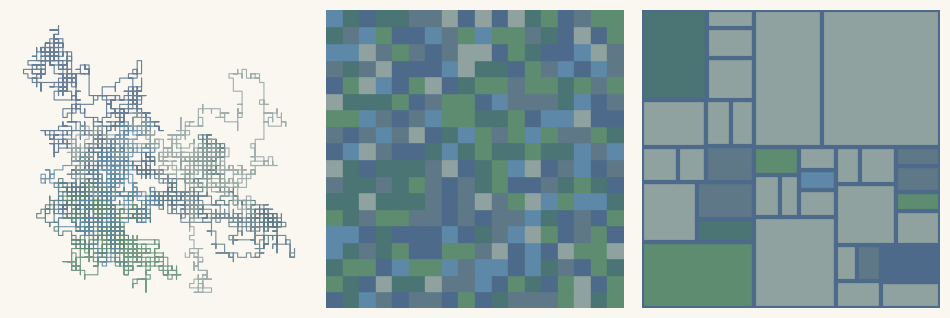

In [17]:
# the triptych: three chapters, one extracted palette
def palette_triptych(palette_name, seed=3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), facecolor=PAPER)
    walk_panel(axes[0], palette_name, seed=seed)
    grid_panel(axes[1], palette_name, seed=seed)
    mondrian_panel(axes[2], palette_name, seed=seed)
    fig.subplots_adjust(wspace=0.06)
    plt.show()
    return fig

art_1 = palette_triptych("monet")

## Playground

To make the whole pipeline reusable, `extract_palette` wraps today's build-up into one function: image in, palette out. Then we let two more paintings from the course folder recolor the same three machines. (All seeds are fixed, as always; change them freely. **Try it:** `n_colors=3` versus `n_colors=12` on the Monet changes the triptych's whole climate.)

In [18]:
# the whole pipeline in one function: image in, hex palette out
def extract_palette(image_path, n_colors=6, width=360):
    image = Image.open(image_path)
    height = int(image.height * width / image.width)
    small = np.asarray(image.convert("RGB").resize((width, height))) / 255
    lab = rgb2lab(small)          # convert("RGB") tames grayscale and RGBA files
    kmeans = KMeans(n_clusters=n_colors, n_init=10, random_state=0)
    kmeans.fit(lab.reshape(-1, 3))
    centers = kmeans.cluster_centers_
    order = np.argsort(centers[:, 0])              # dark to light
    rgb = lab2rgb(centers[order].reshape(1, n_colors, 3)).reshape(n_colors, 3)
    palette = []
    for center in rgb:
        palette.append(to_hex(center))
    return palette

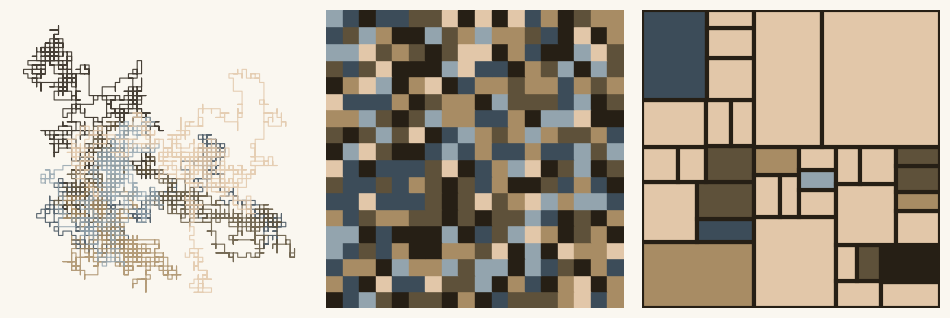

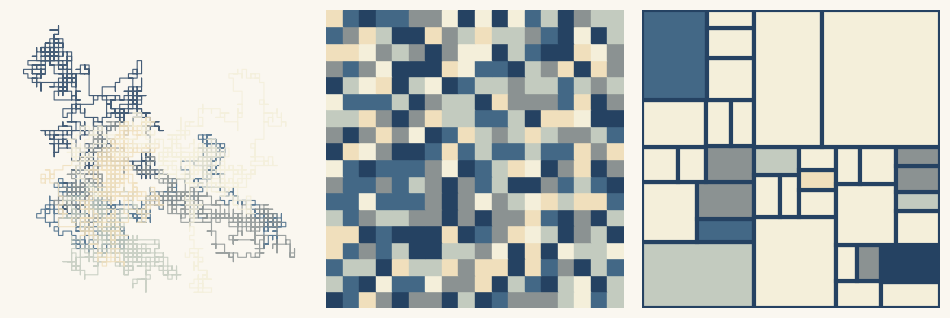

In [19]:
# Vermeer and Hokusai recolor the same three machines
PALETTES["vermeer"] = extract_palette("../assets/images/vermeer_pearl_earring.jpg")
PALETTES["hokusai"] = extract_palette("../assets/images/hokusai_wave.jpg")

art_2 = palette_triptych("vermeer")
art_3 = palette_triptych("hokusai")

**Look and compare.** Three palettes, identical seeds: the compositions are the same, stroke for stroke and field for field, only the colors changed. Which triptych feels calmest, and is that a property of the source painting or of its palette alone? Does the Hokusai version remind you of the wave at all, and if it does not, what did the palette fail to carry: the hues, the proportions, or the *placement* of color? (That last one is the deep question: a palette is a list, a painting is an arrangement.)

## Export your artwork

Extract a palette from any image you like (drop a file into `assets/images/`, or reuse the course paintings), pick your favorite generator or the whole triptych, replace `yourname`, and run; the print-quality PNG lands in `assets/outputs/`.

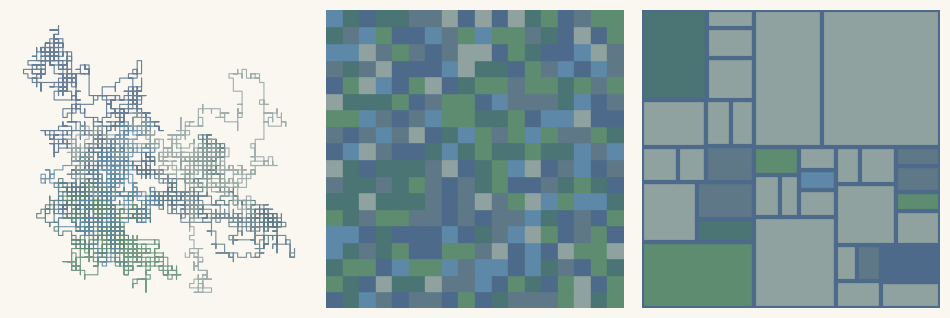

saved: assets/outputs/ch05_yourname.png


In [20]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = palette_triptych("monet", seed=3)
saved_path = save_artwork(my_artwork, "yourname", chapter=5)

## Exercises

**(a) Parameter exploration: what is "the" palette of a painting?** Run `extract_palette` on the Monet with `n_colors=3` and `n_colors=12` and display the results (the swatch code from the build-up works). At $k=3$, which aspects of the painting survive? At $k=12$, do the extra colors add identity or noise? There is no correct $k$; write one sentence defending your favorite, and note what that implies about the phrase "the palette of a painting".

**(b) Code modification: sort by hue.** Our palettes are sorted by lightness. Write `sort_palette_by_hue(palette)` that re-orders a list of hex colors by their hue instead, using `colorsys.rgb_to_hsv` (and `matplotlib.colors.to_rgb` to parse the hex strings). Show the Monet palette both ways. One subtlety: hue lives on a wheel (remember `% 1.0` from chapter 2), so "sorted by hue" depends on where you cut the wheel; where does your sort cut it?

<details><summary>Solution</summary>

```python
from matplotlib.colors import to_rgb

def sort_palette_by_hue(palette):
    hues = []
    for hex_color in palette:
        r, g, b = to_rgb(hex_color)
        hue, saturation, value = colorsys.rgb_to_hsv(r, g, b)
        hues.append(hue)
    order = np.argsort(hues)
    sorted_palette = []
    for index in order:
        sorted_palette.append(palette[index])
    return sorted_palette

by_hue = sort_palette_by_hue(PALETTES["monet"])
print(by_hue)

swatch = np.zeros((1, len(by_hue), 3))
for i in range(len(by_hue)):
    swatch[0, i] = to_rgb(by_hue[i])
plt.figure(figsize=(8, 1.4))
plt.imshow(swatch)
plt.axis("off")
plt.title("the Monet palette, sorted by hue")
plt.show()
```

The sort cuts the wheel at hue 0, which is red: colors just below pure red (a warm pink at hue 0.97) land at the *end* while near-identical reds at hue 0.02 land at the *start*. A fancier version subtracts an offset before sorting to cut the wheel at its emptiest point.
</details>

**(c) Creative challenge: your personal palette.** Photograph something whose colors feel like yours (a bookshelf, a jacket, a street corner), extract its palette, register it in `PALETTES` under your name, and recolor one generator from any previous chapter with it. Keep the palette; the course galleries ahead (flow fields in chapter 8 above all) will make far heavier use of it than today's triptych.

## Further reading

- Josef Albers, *Interaction of Color* (1963; Yale 50th-anniversary edition 2013): short chapters, revolutionary plates; the [companion app](https://interactionofcolor.com/) lets you re-run his experiments interactively.
- Johannes Itten, *The Art of Color* (*Kunst der Farbe*, 1961): the Bauhaus color system, contrasts and all; skim plate-first.
- John Gage, *Colour and Culture: Practice and Meaning from Antiquity to Abstraction* (1993): the standard art-historical survey of color's shifting meanings.
- Bartosz Ciechanowski, ["Color Spaces"](https://ciechanow.ski/color-spaces/): a superb interactive essay walking from RGB to perceptual spaces; the best hour you can spend on this chapter's math.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

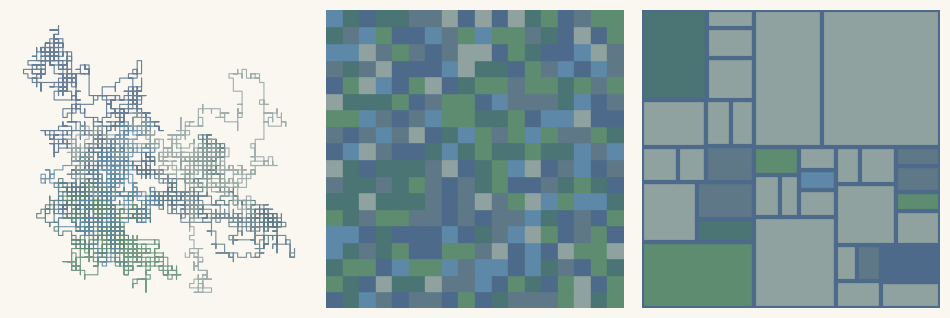

saved: assets/outputs/ch05_showpiece.png


In [21]:
# regenerate this chapter's showpiece: the Monet triptych
showpiece = palette_triptych("monet", seed=3)
saved_path = save_artwork(showpiece, "showpiece", chapter=5)